In [1]:
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import time

# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, LSTM

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# accuracy score for evaluating model
from sklearn.metrics import accuracy_score

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# resample signal to n samples
from scipy.signal import resample

# XML parser
import xml.etree.ElementTree as ET

# encoding and normalizing data
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
NUM_POINTS = 50

## Read Data

Strokes are resampled with arc-length linear interpolation (`resample_path`), not `scipy.signal.resample`. The FFT resampler assumes a smooth periodic signal and rings at sharp corners and open endpoints, blurring corner-heavy shapes (rectangle, triangle, x, delete_mark). Using the interpolation method used by the $1 recognizer improved the accuracy of the LSTM.

In [3]:
def resample_path(points, n):
    points = np.asarray(points, dtype=float)
    seg = np.sqrt((np.diff(points, axis=0) ** 2).sum(axis=1))  # segment lengths
    cum = np.concatenate([[0.0], np.cumsum(seg)])  # cumulative length up to each point, add 0 for the first point
    if cum[-1] == 0:
        return np.repeat(points[:1], n, axis=0)  # if distance is 0, return n copies of the first point
    interval = cum[-1] / (n - 1)  # desired distance between resampled points
    target = np.arange(n) * interval  # target cumulative lengths for resampled points
    x = np.interp(target, cum, points[:, 0])
    y = np.interp(target, cum, points[:, 1])
    return np.stack([x, y], axis=1)


def load_gestures(base_dir):
    samples = []
    for root, subdirs, files in os.walk(base_dir):
        if 'ipynb_checkpoint' in root:
            continue

        for f in tqdm(files, desc=root, leave=False):
            if '.xml' not in f:
                continue

            # filename "<class><NN>.xml" -> drop ".xml" and the number
            label = f.split('.')[0][:-2]

            xml_root = ET.parse(f'{root}/{f}').getroot()

            points = []
            for element in xml_root.findall('Point'):
                x = element.get('X')
                y = element.get('Y')
                points.append([x, y])

            points = np.array(points, dtype=float)
            if len(points) < 2:
                continue

            scaler = StandardScaler()
            points = scaler.fit_transform(points)

            resampled = resample_path(points, NUM_POINTS)

            samples.append((label, resampled))
    return samples


# train on the Wobbrock logs, test on my own recordings
data = load_gestures('datasets/wobbrock')
test_set = load_gestures('datasets/custom')

print(f'training samples (Wobbrock): {len(data)}')
print(f'recorded test samples:       {len(test_set)}')

datasets/wobbrock: 0it [00:00, ?it/s]

datasets/wobbrock\s01: 0it [00:00, ?it/s]

datasets/wobbrock\s01\fast:   0%|          | 0/160 [00:00<?, ?it/s]

datasets/wobbrock\s01\medium:   0%|          | 0/160 [00:00<?, ?it/s]

datasets/wobbrock\s01\slow:   0%|          | 0/160 [00:00<?, ?it/s]

...

datasets/wobbrock\s11\medium:   0%|          | 0/160 [00:00<?, ?it/s]

datasets/wobbrock\s11\slow:   0%|          | 0/160 [00:00<?, ?it/s]

datasets/custom: 0it [00:00, ?it/s]

datasets/custom\s1:   0%|          | 0/160 [00:00<?, ?it/s]

training samples (Wobbrock): 5280
recorded test samples:       160


In [4]:
print(data[0])

('arrow', array([[-1.98115675e+00,  1.98053787e+00],
       [-1.96374517e+00,  1.86286363e+00],
       [-1.82386999e+00,  1.72281834e+00],
       [-1.69498850e+00,  1.57213912e+00],
       [-1.57703324e+00,  1.41274782e+00],
       [-1.44120197e+00,  1.26756688e+00],
       [-1.30773202e+00,  1.12017256e+00],
       [-1.15890309e+00,  9.88326683e-01],
       [-1.00988355e+00,  8.56673770e-01],
       [-8.62251830e-01,  7.23518914e-01],
       [-7.19257366e-01,  5.85345485e-01],
       [-5.59184923e-01,  4.69785335e-01],
       [-3.93644449e-01,  3.61465509e-01],
       [-2.50649985e-01,  2.23292080e-01],
       [-9.07805835e-02,  1.07463079e-01],
       [ 7.62664739e-02,  8.22835640e-04],
       [ 2.25286016e-01, -1.30830077e-01],
       [ 3.90939550e-01, -2.38867873e-01],
       [ 5.44109152e-01, -3.65125200e-01],
       [ 7.00480286e-01, -4.85565948e-01],
       [ 8.67817528e-01, -5.91872289e-01],
       [ 7.45807497e-01, -6.82962659e-01],
       [ 5.55641167e-01, -6.54617417e-01],
 

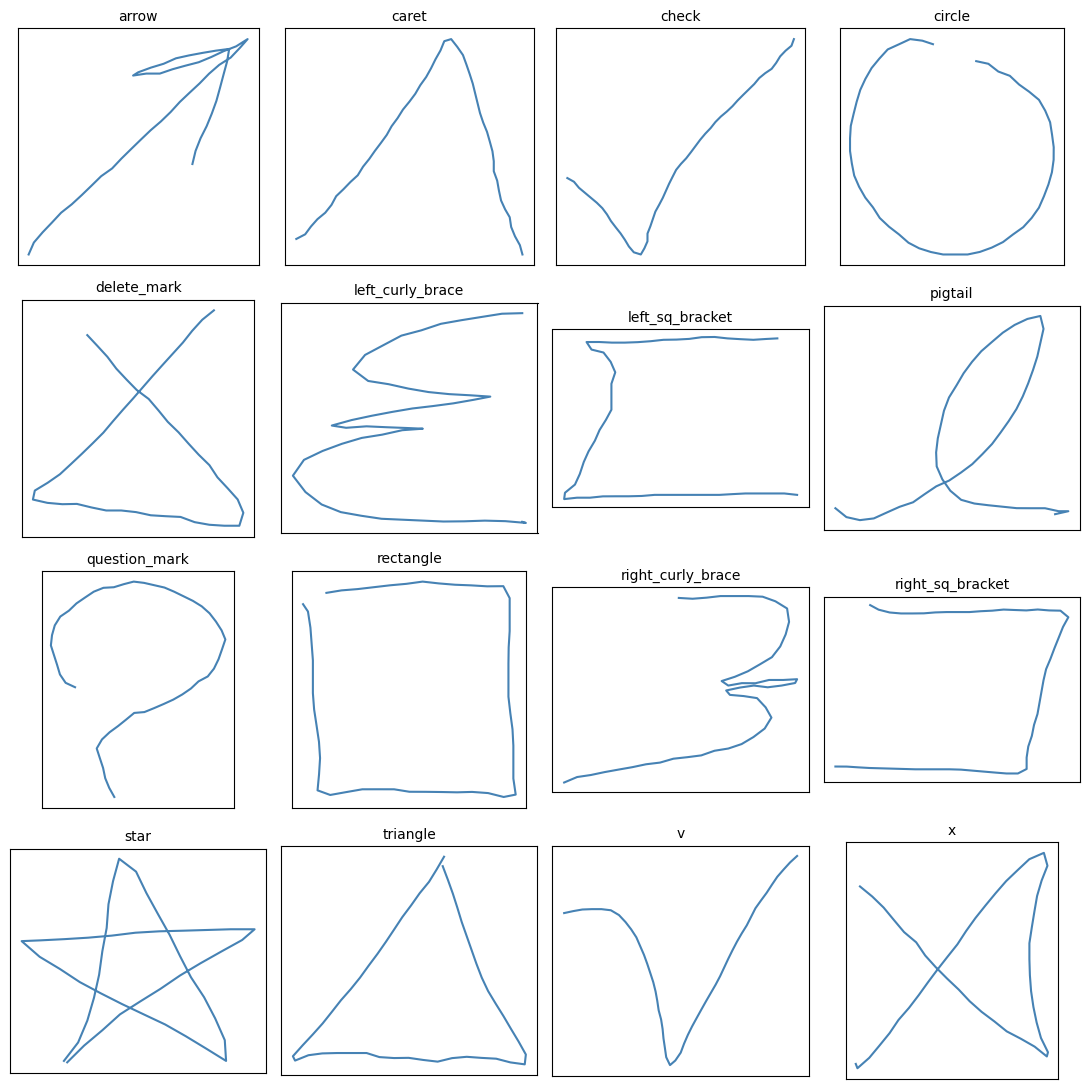

In [5]:
by_class = {}
for label, seq in data:
    by_class.setdefault(label, []).append(seq)

classes = sorted(by_class)
random.seed(1)

fig, axes = plt.subplots(4, 4, figsize=(11, 11))
for ax, cls in zip(axes.flat, classes):
    seq = random.choice(by_class[cls])
    # y is flipped so the stroke looks the same way it was drawn
    ax.plot(seq.T[0], seq.T[1] * -1, color="steelblue")
    ax.set_title(cls, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

plt.tight_layout()

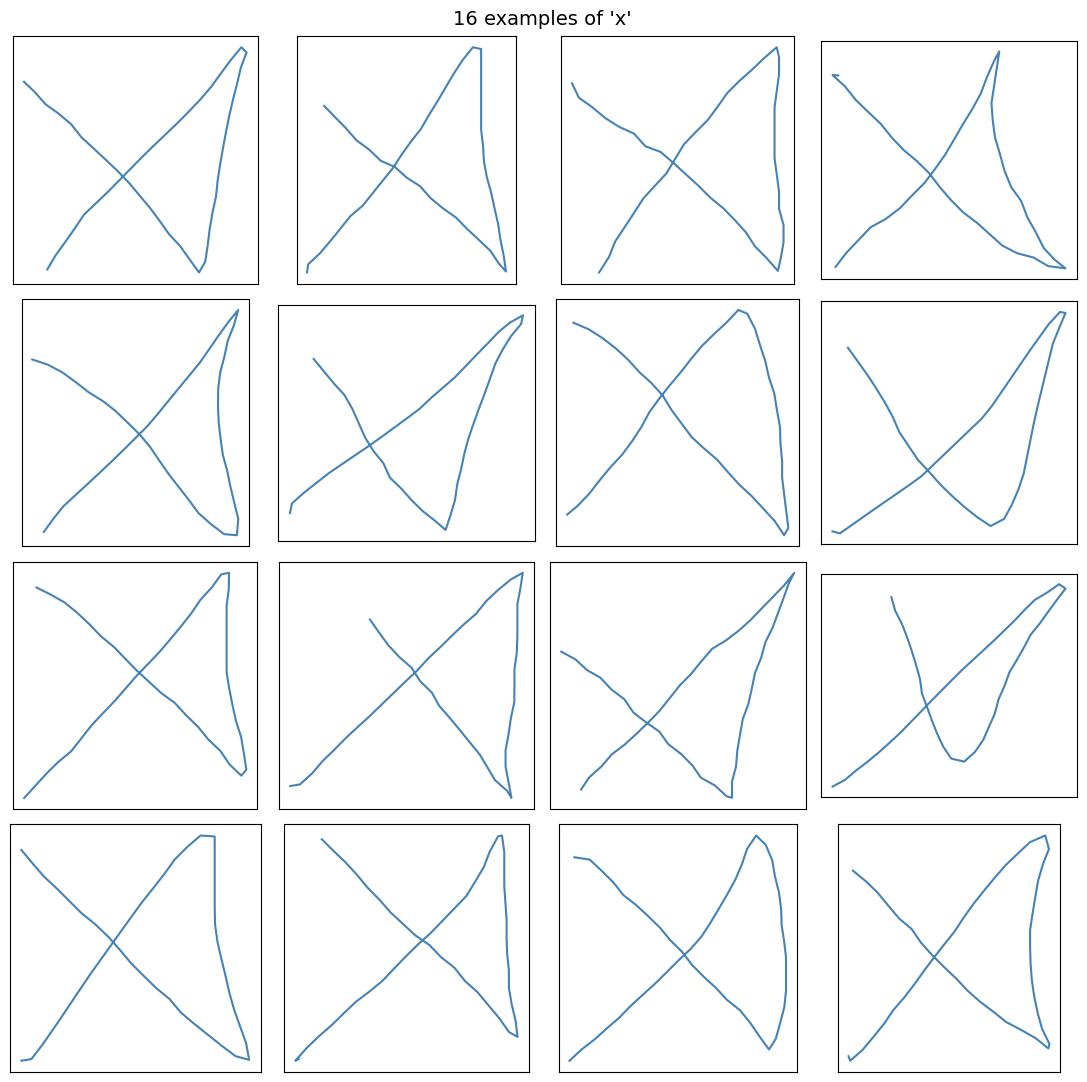

In [6]:
cls = "x"

samples = [seq for label, seq in data if label == cls]

random.seed(1)
chosen = random.sample(samples, 16)

fig, axes = plt.subplots(4, 4, figsize=(11, 11))
for ax, seq in zip(axes.flat, chosen):
    # y is flipped so the stroke looks the same way it was drawn
    ax.plot(seq.T[0], seq.T[1] * -1, color="steelblue")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

fig.suptitle(f"16 examples of '{cls}'", fontsize=14)
plt.tight_layout()

## Prepare Data

In [7]:
labels = [sample[0] for sample in data]
print("labels: ", sorted(set(labels)))

encoder = LabelEncoder()
encoder.fit(labels)
print("num labels (encoded): ", len(encoder.classes_))


def to_xy(samples):
    X = np.array([s[1] for s in samples])
    y = to_categorical(encoder.transform([s[0] for s in samples]),
                       num_classes=len(encoder.classes_))
    return X, y


X_train, y_train = to_xy(data)

if test_set:
    # keep only classes the model was actually trained on
    known = set(encoder.classes_)
    test_set = [s for s in test_set if s[0] in known]
    X_test, y_test = to_xy(test_set)
    print("test set: our own recordings")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42)
    print("test set: random hold-out of Wobbrock data (no recordings found)")

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

labels:  ['arrow', 'caret', 'check', 'circle', 'delete_mark', 'left_curly_brace', 'left_sq_bracket', 'pigtail', 'question_mark', 'rectangle', 'right_curly_brace', 'right_sq_bracket', 'star', 'triangle', 'v', 'x']
num labels (encoded):  16
test set: our own recordings
(5280, 50, 2) (160, 50, 2) (5280, 16) (160, 16)


## Define and Train Model (in class)

In [8]:
model = Sequential()

# add LSTM layer
# input shape is (length of an individual sample, dimensions of the sample)
# in our case: two dimensions, as we have X and Y coordinates

# old syntax
#model.add(LSTM(64, input_shape=(NUM_POINTS, 2)))

# new syntax
model.add(Input((NUM_POINTS, 2)))
model.add(LSTM(64))

# add dense layer to do machine learning magic
model.add(Dense(32, activation='relu'))

# here, you can add more layers and maybe a dropout for better performance

# softmax layer for classification
model.add(Dense(len(set(labels)), activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
stop_early = EarlyStopping(monitor='val_loss', patience=3)

In [9]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.6581 - loss: 1.1819 - val_accuracy: 0.8375 - val_loss: 0.4880 - learning_rate: 0.0010
Epoch 2/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9428 - loss: 0.1883 - val_accuracy: 0.9062 - val_loss: 0.3391 - learning_rate: 0.0010
Epoch 3/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9763 - loss: 0.0892 - val_accuracy: 0.9187 - val_loss: 0.2779 - learning_rate: 0.0010
Epoch 4/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.9847 - loss: 0.0610 - val_accuracy: 0.9187 - val_loss: 0.2761 - learning_rate: 0.0010
Epoch 5/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.9828 - loss: 0.0594 - val_accuracy: 0.9438 - val_loss: 0.2346 - learning_rate: 0.0010
Epoch 6/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.9875 - loss: 0.0453 - val_accuracy: 0.9563 - val_loss: 0.2147 - learning_rate: 0.0010
Epoch 7/10
165/165 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.9917 - l

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,282 (231.57 KB)

 Trainable params: 19,760 (77.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,522 (154.39 KB)

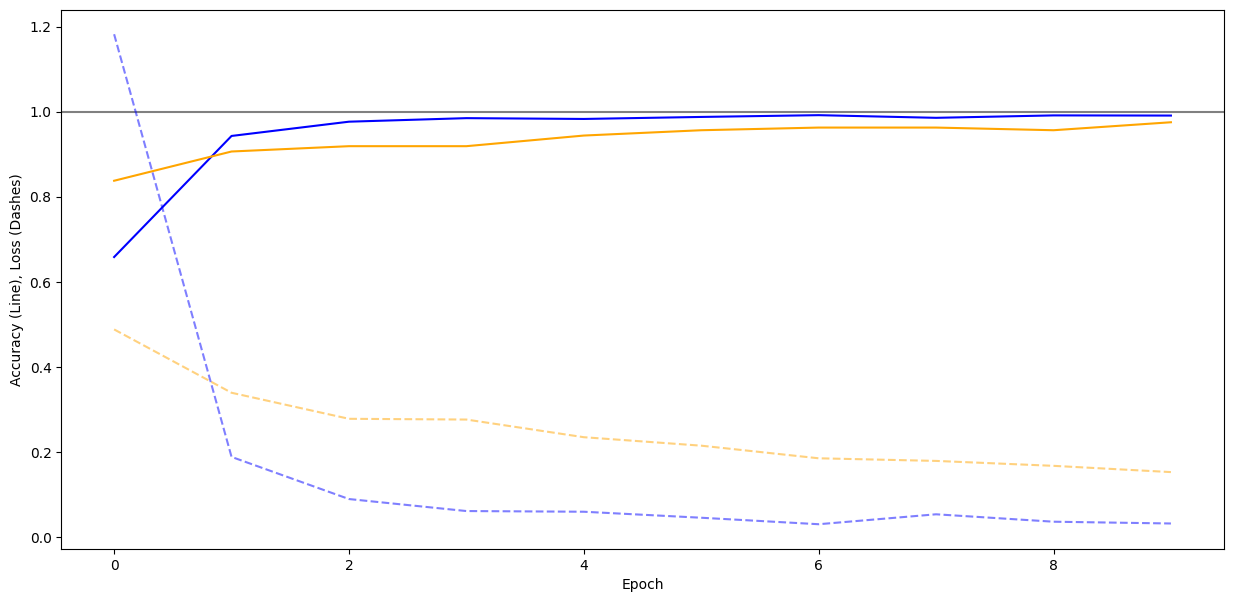

In [11]:
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

fig = plt.figure(figsize=(15, 7))
ax = plt.gca()

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (Line), Loss (Dashes)')

ax.axhline(1, color='gray')

plt.plot(accuracy, color='blue')
plt.plot(val_accuracy, color='orange')
plt.plot(loss, '--', color='blue', alpha=0.5)
plt.plot(val_loss, '--', color='orange', alpha=0.5)

## Predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
true label:   right_curly_brace
prediction:   right_curly_brace 0.99648076


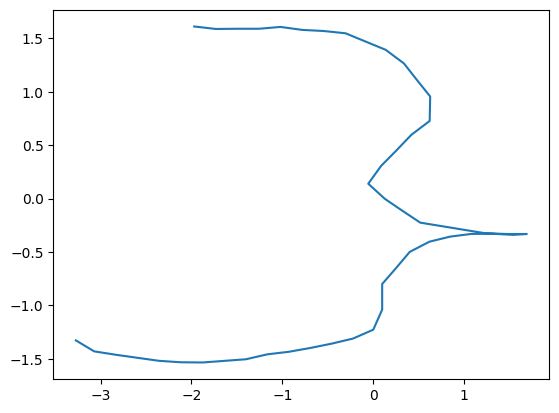

In [12]:
# lets test the model in action

# take a random sample of test data and visualize
test_data = random.sample(data, 1)[0]
label = test_data[0]
sequence = test_data[1]
plt.plot(sequence.T[0], sequence.T[1] * -1)

# predict
prediction = model.predict(np.array([sequence]))

prediction_label_encoded = np.argmax(prediction)
prediction_label = encoder.inverse_transform(np.array([prediction_label_encoded]))[0]

print('true label:  ', label)
print('prediction:  ', prediction_label, prediction.max())

In [13]:
# make predictions for all the samples in test data
y_pred = model.predict(X_test, verbose=0)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print("predicted", len(y_pred_labels), "test samples")

predicted 160 test samples


In [14]:
# print accuracy of model on test data
baseline_acc = accuracy_score(y_true_labels, y_pred_labels)
print(f"baseline LSTM test accuracy: {baseline_acc:.3f}")

baseline LSTM test accuracy: 0.975


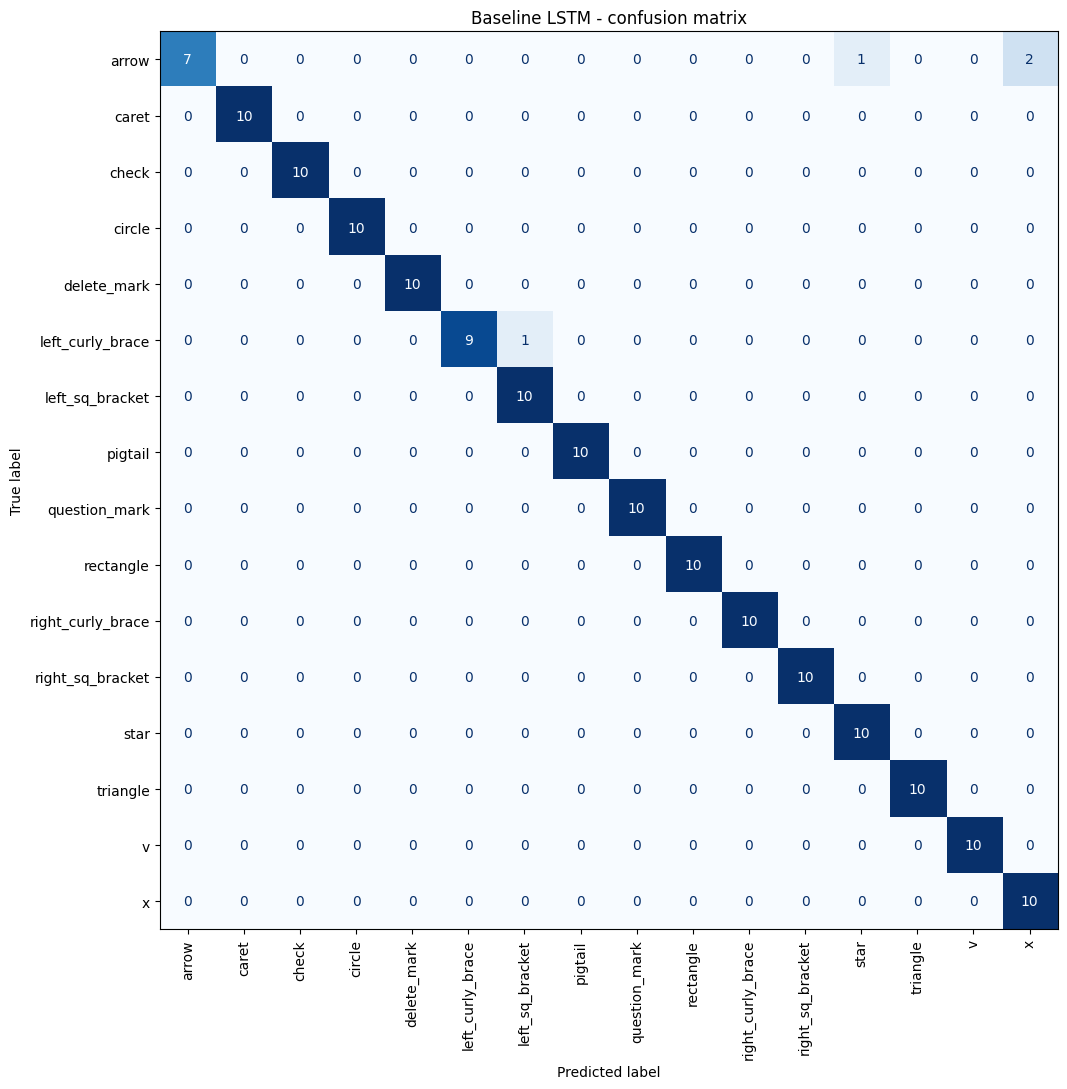

In [15]:
# show confusion matrix
fig, ax = plt.subplots(figsize=(11, 11))
ConfusionMatrixDisplay.from_predictions(
    y_true_labels, y_pred_labels,
    display_labels=encoder.classes_,
    xticks_rotation="vertical",
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Baseline LSTM - confusion matrix")
plt.tight_layout()

## Comparing Parameter Counts and the $1 Recognizer
All modells trained on the Wobbrock dataset and are tested on my own recordings.

In [16]:
train_samples, eval_samples = data, test_set

X_tr, y_tr = to_xy(train_samples)
X_ev, y_ev = to_xy(eval_samples)
num_classes = len(encoder.classes_)

print(f"train: {len(train_samples)} samples, test: {len(eval_samples)} samples")

train: 5280 samples, test: 160 samples


In [17]:
#-LSTM classifier with configurable size
def build_lstm(lstm_units, dense_units):
    m = Sequential()
    m.add(Input((NUM_POINTS, 2)))
    m.add(LSTM(lstm_units))
    if dense_units:
        m.add(Dense(dense_units, activation="relu"))
    m.add(Dense(num_classes, activation="softmax"))
    m.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return m


def train_and_eval(name, lstm_units, dense_units, epochs=15):
    model = build_lstm(lstm_units, dense_units)

    callbacks = [
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-4),
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ]
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=32,
              validation_data=(X_ev, y_ev), verbose=0, callbacks=callbacks)

    accuracy = model.evaluate(X_ev, y_ev, verbose=0)[1]

    # per-sample latency, one stroke at a time like a live app
    _ = model(X_ev[:1], training=False)  # warm up
    start = time.perf_counter()
    for i in range(len(X_ev)):
        model(X_ev[i:i + 1], training=False)
    latency_ms = (time.perf_counter() - start) / len(X_ev) * 1000

    print(f"{name:10s}  params={model.count_params():6d}  "
          f"acc={accuracy:.3f}  latency={latency_ms:.3f} ms/sample")
    return {"name": name, "params": model.count_params(),
            "accuracy": accuracy, "latency_ms": latency_ms, "model": model}

In [18]:
results = []
results.append(train_and_eval("LSTM-64", 64, 32))  # baseline from the provided notebook
results.append(train_and_eval("LSTM-48", 48, 24))
results.append(train_and_eval("LSTM-32", 32, 16))
results.append(train_and_eval("LSTM-24", 24, 12))
results.append(train_and_eval("LSTM-16", 16, 8))
results.append(train_and_eval("LSTM-8", 8, 4))
results.append(train_and_eval("LSTM-4", 4, 2))

LSTM-64     params= 19760  acc=0.944  latency=247.427 ms/sample
LSTM-48     params= 11368  acc=0.975  latency=227.179 ms/sample
LSTM-32     params=  5280  acc=0.956  latency=234.590 ms/sample
LSTM-24     params=  3100  acc=0.919  latency=241.249 ms/sample
LSTM-16     params=  1496  acc=0.825  latency=306.827 ms/sample
LSTM-8      params=   468  acc=0.463  latency=189.107 ms/sample
LSTM-4      params=   170  acc=0.444  latency=199.217 ms/sample


### $1 recognizer on the same test set

Five templates per class is a compromise: enough examples to capture the natural variation in how each shape is drawn, while keeping the per-stroke search cheap, since $1's cost grows linearly with the total number of templates.

In [24]:
from recognizer import Recognizer

def to_points(sample_pts):
    return [(float(x), float(y)) for x, y in sample_pts]

def preprocess_template(rec, pts):
    pts = rec.resample(to_points(pts), 64)
    pts = rec.rotate_by(pts, -rec.indicative_angle(pts))
    pts = rec.scale_to(pts, 250)
    pts = rec.translate_to(pts, (0, 0))
    return pts

# 5 templates per class from the training split, fixed seed picks the same ones every run
TEMPLATES_PER_CLASS = 5
helper = Recognizer([])

by_class = {}
for label, pts in train_samples:
    by_class.setdefault(label, []).append(pts)

random.seed(42)
templates = []
for label, plist in by_class.items():
    chosen = random.sample(plist, min(TEMPLATES_PER_CLASS, len(plist)))
    for pts in chosen:
        templates.append({"name": label, "points": preprocess_template(helper, pts)})

dollar = Recognizer(templates)

dollar_true = []
dollar_pred = []
start = time.perf_counter()
for label, pts in eval_samples:
    name, score = dollar.recognize(to_points(pts))
    dollar_true.append(label)
    dollar_pred.append(name)
elapsed = time.perf_counter() - start

correct = sum(t == p for t, p in zip(dollar_true, dollar_pred))
dollar_acc = correct / len(eval_samples)
dollar_latency = elapsed / len(eval_samples) * 1000
print(f"$1  templates={len(templates)}  acc={dollar_acc:.3f}  "
      f"latency={dollar_latency:.3f} ms/sample")

results.append({"name": f"$1 ({TEMPLATES_PER_CLASS}/class)", "params": None,
                "accuracy": dollar_acc, "latency_ms": dollar_latency, "model": None})

$1  templates=80  acc=0.919  latency=410.391 ms/sample


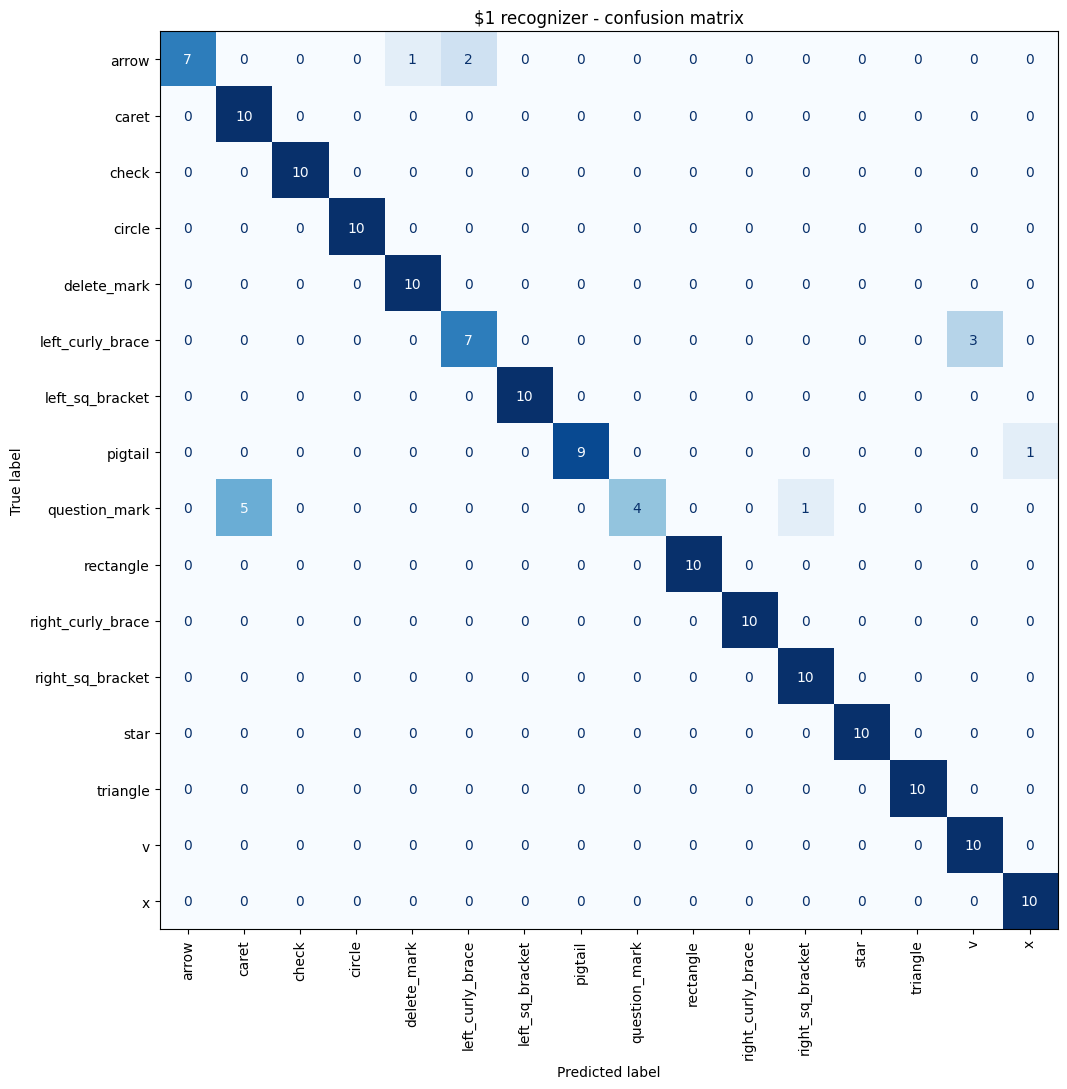

In [20]:
# confusion matrix for the $1 recognizer
fig, ax = plt.subplots(figsize=(11, 11))
ConfusionMatrixDisplay.from_predictions(
    dollar_true, dollar_pred,
    labels=sorted(encoder.classes_),
    xticks_rotation="vertical",
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("$1 recognizer - confusion matrix")
plt.tight_layout()

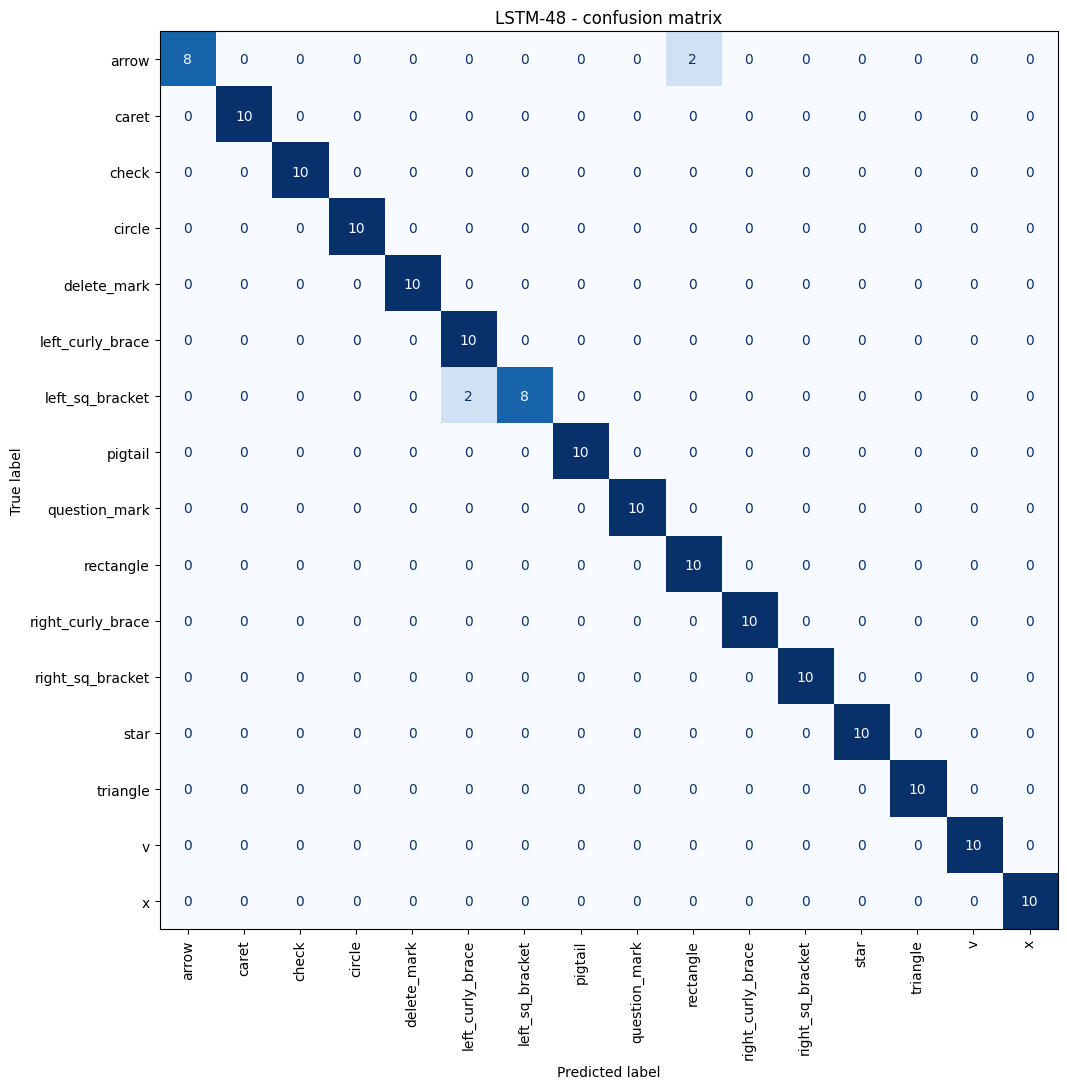

In [21]:
# confusion matrix for the best LSTM (LSTM-48)
lstm48 = next(r["model"] for r in results if r["name"] == "LSTM-48")
pred = np.argmax(lstm48.predict(X_ev, verbose=0), axis=1)
true = np.argmax(y_ev, axis=1)

fig, ax = plt.subplots(figsize=(11, 11))
ConfusionMatrixDisplay.from_predictions(
    true, pred,
    display_labels=encoder.classes_,
    xticks_rotation="vertical",
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("LSTM-48 - confusion matrix")
plt.tight_layout()

In [22]:
# Summary table
print(f"{'method':16s}{'params':>10s}{'accuracy':>12s}{'latency (ms)':>16s}")
print("-" * 54)
for r in results:
    params = "-" if r["params"] is None else f"{r['params']:d}"
    print(f"{r['name']:16s}{params:>10s}{r['accuracy']:>12.3f}{r['latency_ms']:>16.3f}")

method              params    accuracy    latency (ms)
------------------------------------------------------
LSTM-64              19760       0.944         247.427
LSTM-48              11368       0.975         227.179
LSTM-32               5280       0.956         234.590
LSTM-24               3100       0.919         241.249
LSTM-16               1496       0.825         306.827
LSTM-8                 468       0.463         189.107
LSTM-4                 170       0.444         199.217
$1 (5/class)             -       0.919         313.547


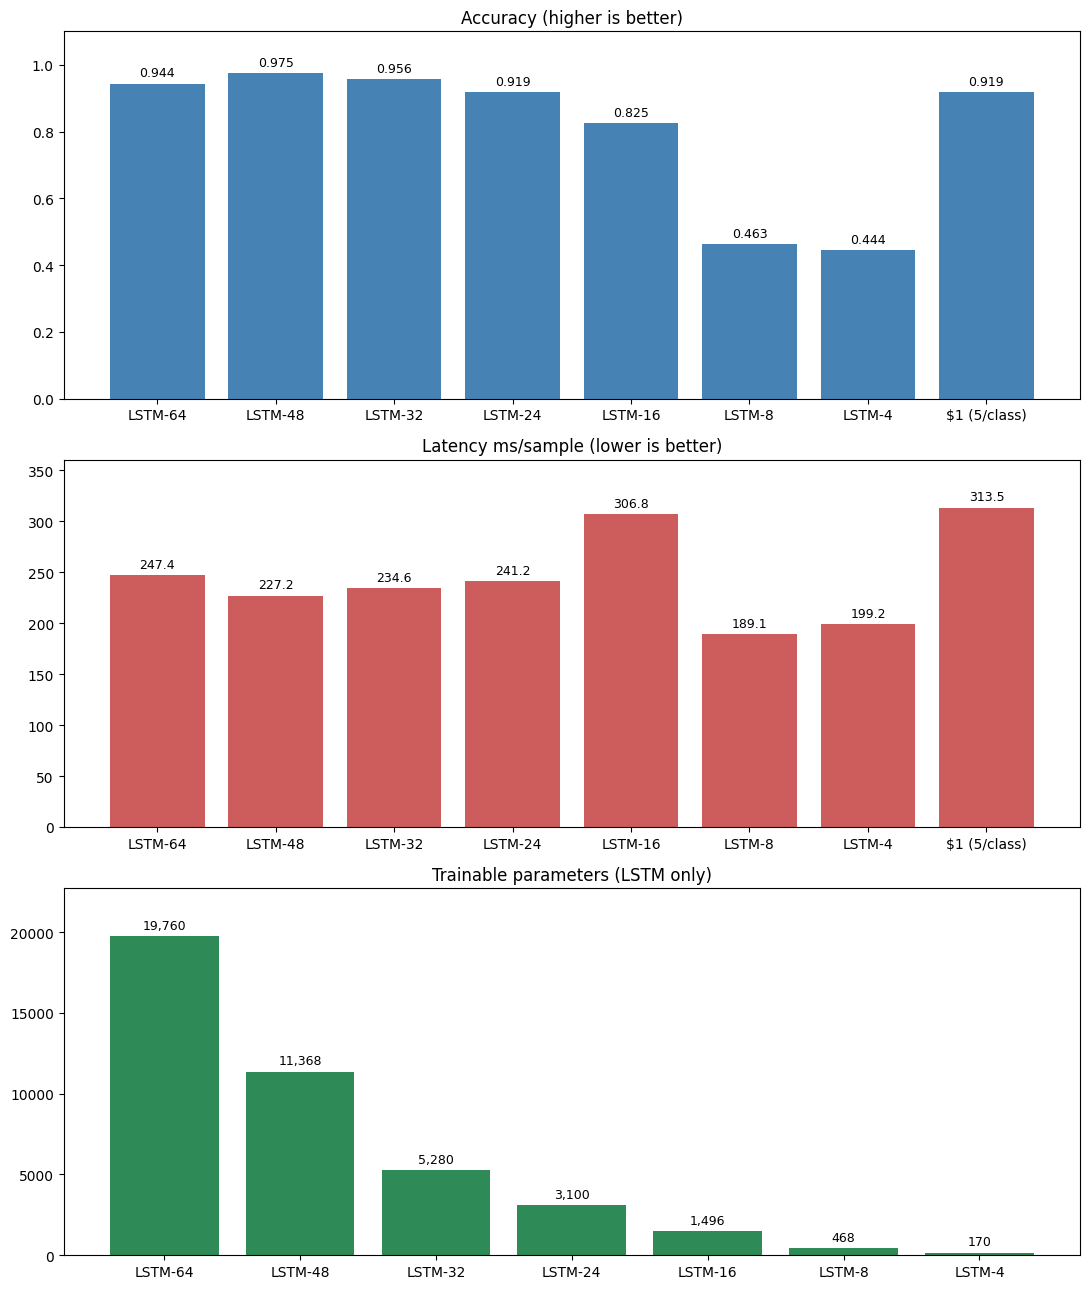

In [23]:
names = [r["name"] for r in results]
accuracies = [r["accuracy"] for r in results]
latencies = [r["latency_ms"] for r in results]

fig, axes = plt.subplots(3, 1, figsize=(11, 13))

b0 = axes[0].bar(names, accuracies, color="steelblue")
axes[0].set_title("Accuracy (higher is better)")
axes[0].set_ylim(0, 1.1)
axes[0].bar_label(b0, labels=[f"{a:.3f}" for a in accuracies], padding=3, fontsize=9)

b1 = axes[1].bar(names, latencies, color="indianred")
axes[1].set_title("Latency ms/sample (lower is better)")
axes[1].set_ylim(0, max(latencies) * 1.15)
axes[1].bar_label(b1, labels=[f"{l:.1f}" for l in latencies], padding=3, fontsize=9)

lstm = [r for r in results if r["params"] is not None]
b2 = axes[2].bar([r["name"] for r in lstm], [r["params"] for r in lstm], color="seagreen")
axes[2].set_title("Trainable parameters (LSTM only)")
axes[2].set_ylim(0, max(r["params"] for r in lstm) * 1.15)
axes[2].bar_label(b2, labels=[f'{r["params"]:,}' for r in lstm], padding=3, fontsize=9)

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

In [ ]:
# visual summary for the conclusion: accuracy vs model size
# (LSTM sizes as a line, the $1 recognizer as a reference)
lstm = sorted((r for r in results if r["params"] is not None),
              key=lambda r: r["params"])
dollar = next(r for r in results if r["params"] is None)

plt.figure(figsize=(8, 5))
plt.plot([r["params"] for r in lstm], [r["accuracy"] for r in lstm],
         "o-", color="steelblue", label="LSTM")
for r in lstm:
    plt.annotate(r["name"].replace("LSTM-", ""),
                 (r["params"], r["accuracy"]),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=8)
plt.axhline(dollar["accuracy"], color="indianred", linestyle="--",
            label=f"$1 recognizer ({dollar['accuracy']:.2f})")
plt.xscale("log")
plt.ylim(0, 1)
plt.xlabel("trainable parameters (log scale)")
plt.ylabel("test accuracy")
plt.title("Accuracy holds until the LSTM gets very small")
plt.legend()
plt.tight_layout()

## Conclusion: which recognizer to choose for a practical application

On the full 16-class test set the **LSTM** comes out ahead:

* **Accuracy** is higher than the $1 recognizer.
* **Orientation**: $1 is rotation invariant, so it confuses shapes that only differ by rotation, the LSTM keeps the absolute orientation and does not.
* **Prediction time** is a bit lower too, since $1 has to search every template per stroke.

So for a large gesture set with training data available, the LSTM is the better choice.

For the **task 3 game** the $1 recognizer is the better fit instead. The game only needs three very different shapes (circle, rectangle, V), where $1 already reaches ~100% accuracy. Because it does not depend on Tensorflow, the game can start instantly. For comparison, I traind a small LSTM trained on the same three shapes.

In [27]:
# small 3-class LSTM on just the game's gestures, for comparison with the $1 recognizer
RPS_CLASSES = ["circle", "rectangle", "v"]
rps_idx = {c: i for i, c in enumerate(RPS_CLASSES)}

def to_rps_xy(samples):
    sel = [(lbl, seq) for lbl, seq in samples if lbl in rps_idx]
    X = np.array([seq for _, seq in sel])
    y = to_categorical([rps_idx[lbl] for lbl, _ in sel], num_classes=3)
    return X, y

Xr_tr, yr_tr = to_rps_xy(data)
Xr_ev, yr_ev = to_rps_xy(test_set)

rps_model = Sequential([
    Input((NUM_POINTS, 2)),
    LSTM(32),
    Dense(16, activation="relu"),
    Dense(3, activation="softmax"),
])
rps_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
rps_model.fit(Xr_tr, yr_tr, epochs=15, batch_size=32, validation_data=(Xr_ev, yr_ev),
              verbose=0, callbacks=[EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)])

acc = rps_model.evaluate(Xr_ev, yr_ev, verbose=0)[1]
print(f"3-class LSTM test accuracy: {acc:.3f}")

3-class LSTM test accuracy: 1.000
